# 1. Теоретическая часть

### 1. Что такое метод «исключения одного элемента» (leave-one-out)? Укажите его ограничения и сильные стороны.

Leave one out - это частный случай K-Fold, где K=N (N - размер выборки). То есть в тестовую выборку уходит 1 экземпляр, а остальные в тренировочную. Далее мы берем следующий один экземпляр для теста, а остальные отправляем в тренировочную выборку. После того, как мы протестировали качество нашей модели на N элементов, мы выводим усредненную метрику

    Сильные стороны: Максимально использует все данные для обучения, низкое смещение данных, полезен для маленьких датасетов, где каждый объект очень важен
    Слабые стороны: Вычислительно очень дорогой, высокая вероятность переобучения 

### 2. Как работают алгоритмы поиска по сетке (Grid Search), случайного поиска по сетке (Randomized Grid Search) и байесовской оптимизации (Bayesian optimization)?

1. Grid Search - это полный перебор всех комбинаций заранее заданных гиперпараметров. 
    
        Плюсы: Если в наборе данных есть гиперпараметры, дающие оптимум лосс функции модели, то GridSearch точно их найдет, прост для понимания (просто перебор)
        Минусы: Очень дорог в вычислениях (O(m^k) для k параметров по m вариантов на гиперпараметр) + не учитывает зависимости между гиперпараметрами

2.  Randomized GS - вместо полного перебора как в GS здесь случайный образом берется фиксированное N кол-во комбинаций из заданного распределения гиперпараметров
    
        Плюсы: Отрабатывает быстрее GS засчет фиксированного количества комбинаций. Полезен на больших данных (т.к на больших данных классический GS бесполезен – будет работать очень долго)
        Минусы: Нет никакой гарантии найти глобальный оптимум (лучшие значения гиперпараметров, позволяющее получить лучшее качество модели по заданной метрике) + как GS не учитывает зависимость гиперпараметров 

3. Байесовская оптимизация - последовательный поиск значений, который "учится" на предыдущих данных. Использует вероятностную модель предсказания нахождения оптимума, на каждой итерации выбирает между вероятностями следующего шага 

        Плюсы: Очень эффективен, учитывает зависимости гиперпараметров друг от друга 
        Минусы: Более сложен в понимании как идеи, достаточно дорог в вычислениях

### 3. (1) Объясните классификацию методов отбора признаков (feature selection)
### (2) Объясните, как работают коэффициенты Пирсона и хи-квадрат. 
### (3) Объясните, как работает метод Lasso. 
### (4) Объясните, что такое значимость перестановок. 
### (5) Ознакомьтесь с методом SHAP.

#### (1) Объясните классификацию методов отбора признаков (feature selection)

* **Unsupervised**: 
        
      Variance Threshold (удаление признаков с дисперсией, ниже заданной), удаление сильно коррелирующих признаков, удаление признаков с большим кол-вом пропусков 


* **Supervised**:  

        1. Методы фильтрации - корреляция пирсона (для числовых) (+ корреляция спирмена, кендалла), 
        chi2 для номинальных, ANOVA, F-value  

        2. Метод обертки (основная идея метода заключается в поиске всевозможных признаков и оценки их качества 
        путем прогона через модель) - метод прямого отбора, метод обратного отбора 

        3. Встоенные алгоритмы - L1-регуляризация (может занулить коэф. незнач. признаков)
        L2-регуляризация(приближает к 0 коэф. незнач. признаков), ElasticNet (L1 + L2)

#### (2) Объясните, как работают коэффициенты Пирсона и хи-квадрат. 

#### Пирсон: считает линейную зависимость между двумя числовыми признаками. Он показывает, насколько изменения одной переменной связаны с другой 

#### Формула:
$$
r = \frac{\sum((x_{i}-x_{mean}) * (y_{i}-y_{mean}))}{\sqrt{\sum(x_{i}-x_{mean})^2} * \sum(y_{i} - y_{mean})^2} 
$$


#### Хи-квадрат: объясняет связь между двумя категориальными переменными. Строится таблица сопряженности и проверяется связь факторов по формуле: 

$$
\chi^2 = \sum_{i,j} \frac{(O_{ij} - E_{ij})^2}{E_{ij}}
$$
где
$  O_{ij}  $ — наблюдаемое значение в ячейке, $  E_{ij}  $ — ожидаемое значение в ячейке

#### (3) Объясните, как работает метод Lasso.

#### Lasso может занулить неважные признаки (то есть отбор признаков происходит автоматически)  

#### (4) Объясните, что такое значимость перестановок. 
#### Выбирается случайный признак (столбец) в выборке, рандомным образом значения меняются местами и делают предсказание с новым "неправильным" столбцом. Нужно это для того, чтобы замерить, насколько сильно влияет признак на итоговое предсказание модели

* #### Чем сильнее просела метрика, тем важнее признак в модели

#### (5) Ознакомьтесь с методом SHAP.

#### SHAP - это математический способ разделить вклад каждого признака за полученный результат (т.е предсказание модели)

Идея SHAP: 
1. Есть базовое значение (обычно ср.предсказание по выборке) - это стартавое значение 
2. Для каждого конкретного объекта модель делает предскзаание 
3. SHAP показывает, насколько каждый признак повлиял на предсказание. Более неформально: насколько каждый признак "толкал" точность предсказания вверх или вниз от базового значения до финального 

ПРИМЕР:

* Базовое значение (средняя вероятность дефолта клиента) = 0.12
* Финальное предсказание для клиента = 0.78

SHAP скажет примерно так:
* +0.32 — из-за высокого дохода
* +0.21 — из-за возраста > 50 
* -0.09 — из-за большого количества кредитов
* +0.18 — из-за региона

# 1.1 Импорт библиотек

In [2]:
import pandas as pd
import numpy as np
import shap
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import Lasso
from sklearn.preprocessing import MinMaxScaler
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, GroupKFold, StratifiedKFold, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.model_selection import train_test_split
from collections import Counter


import warnings
warnings.filterwarnings('ignore')

# 1.2 Реализация классов и функций

## Фун-я подсчета метрик для модели

In [3]:
def calculate_metrics(y_true, y_pred, model_name):
    
    return pd.DataFrame({
        'model': model_name,
        'R2': r2_score(y_true, y_pred),
        'MAE': mean_absolute_error(y_true, y_pred),
        'RMSE': np.sqrt(mean_squared_error(y_true, y_pred)), 
        'MSE': mean_squared_error(y_true, y_pred)
    }, index=[0])

## Фун-я отбора признаков по корреляции с целевой 

In [4]:
def simple_features_selection(
    X: pd.DataFrame | pd.Series, 
    y: pd.Series | pd.DataFrame, 
    max_nan_ratio: float = 0.5, 
    top_n: int = 10, 
    corr_method: str = 'pearson') -> list[str]: 
    """
    Простой отбор признаков:
    1. Удаляем признаки с долей NaN > max_nan_ratio
    2. Считаем корреляцию с целевой переменной
    3. Берём top_n признаков с наибольшей |корреляцией|
    """
    
    nan_ratio = X.isna().mean() 
    good_features = nan_ratio[nan_ratio <= max_nan_ratio].index.tolist() # type: ignore
    
    if len(good_features) == 0:
        raise ValueError("Нет признаков с допустимой долей пропусков")
    
    X_good = X[good_features].copy() 
    
    correlations = X_good.corrwith(y, method=corr_method).abs() # type: ignore
    selected_features = correlations.sort_values(ascending=False).head(top_n).index.tolist()
    
    return selected_features

## Фун-я перемешивания признаков

In [5]:
def permutation_features(model, 
                        X: pd.DataFrame, 
                        y: pd.Series | pd.DataFrame, 
                        n_repeats: int = 10, 
                        random_state: int = 21, 
                        metric: str = 'rmse') -> pd.DataFrame: 
    
    """
    Собственная реализация permutation importance из sklearn
    Возвращает DataFrame с важностью признаков:
    
    - importance_mean — среднее ухудшение метрики после перемешивания
    - importance_std  — стандартное отклонение
    
    metric может быть: 'mse', 'rmse', 'mae', 'r2'
    """
    
    y = y.values
    np.random.seed(random_state) 
    
    y_pred = model.predict(X) 
    
    match metric: 
        case 'rmse': 
            baseline = np.sqrt(mean_squared_error(y, y_pred))
            score_func = lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))
        case 'mse': 
            baseline = mean_squared_error(y, y_pred)
            score_func = mean_squared_error
        case 'mae': 
            baseline = mean_absolute_error(y, y_pred) 
            score_func = mean_absolute_error 
        case 'r2': 
            baseline = r2_score(y, y_pred)
            score_func = r2_score
        case _: 
            raise ValueError('Параметр metric должен быть равен одному из следующих значений: "rmse", "mse", "mae", "r2"')
        
    print(f"Baseline {metric.upper()}: {baseline:,.4f}")  
    n_features = X.shape[1]
    importances = np.zeros((n_features, n_repeats))
    X_copy = X.copy() 
    for i, feature_name in enumerate(X.columns): 
        scores = [] 
        
        for _ in range(n_repeats): 
            X_copy = X.copy()
            X_copy[feature_name] = np.random.permutation(X_copy[feature_name])
            
            y_pred_shuffled = model.predict(X_copy) 
            score = score_func(y, y_pred_shuffled) 
            scores.append(score)
        
        importances[i] = scores 
    
    if metric in ['mse', 'rmse', 'mae']: 
        importance_mean = importances.mean(axis=1) - baseline
        imp_std  = importances.std(axis=1)
    else: 
        importance_mean = baseline - importances.mean(axis=1)
        imp_std  = importances.std(axis=1)
    
    return pd.DataFrame({
        'feature': X.columns,
        'importance_mean': importance_mean,
        'importance_std': imp_std}).sort_values('importance_mean', ascending=False).reset_index(drop=True)

## Класс DataSplit 
* Данный класс содержит функции, которые разбивают данные на тренировочные(валидационные) и тестовые в различных условиях
* Реализованные функции:
    * my_train_test_split (аналог train_test_split из sklearn)
    * my_train_valid_test_split (разбивает данные на train, valid и test выборки)
    * my_time_train_test_split (разбивает данные на train и test выборки по дате) 
    * my_time_train_valid_test_split (разбивает данные на train, valid и test выборки по двум диапазонам: date train < date valid < date test)

In [ ]:
class DataSplit: 
    def __init__(self, X: pd.DataFrame | pd.Series, y: pd.DataFrame | pd.Series) -> None:
        self.X = X 
        self.y = y
        # self.df = df.copy() 
        
    def _get_shuffled_indices(self, n: int, shuffle: bool, random_state: int = 21) -> np.ndarray: 
        """
        ## Функция, которая перемешивает индексы перед разбиением
        """
        arr_indices= np.arange(n)
        
        if shuffle: 
            rng = np.random.default_rng(random_state) 
            rng.shuffle(arr_indices)
        
        return arr_indices
     
    def my_train_test_split(self,
                            test_size: float = 0.2, 
                            random_state: int = 21, 
                            shuffle: bool = True) -> tuple[pd.DataFrame|pd.Series, ...]:
        """
        Реализация классического алгоритма test_train_split из sklearn 
        =================================================================
        ## Входные параметры: 
            Обязательные входные параметры: X: pd.DataFrame | pd.Series (признаки) и y: pd.DataFrame | pd.Series (целевая переменная)
            Необязательные параметры: test_size: float (размер тестовой выборки), 
            random_state: int (параметр для воспроизведения алгоритма - получаем одинаковый результат разбиения при различных запусках), 
            shuffle: bool (параметр, отвечающий за перемешивание выборки перед разбиением)
        =================================================================
        ## Выходные параметры: 
            X_train, y_train, X_test, y_test -> 
            tuple[pd.DataFrame|pd.Series, ...] - кортеж разделенных признаков и целевой переменной 
        """
        X = self.X.copy()
        y = self.y.copy()
        n = len(X) 
        
        if not(0 < test_size < 1): 
            raise ValueError('Параметр test_size должен быть в интервале (0, 1)')
        
        test_count = round(n * test_size)
        train_count = n - test_count 
        
        indeces = self._get_shuffled_indices(n, shuffle, random_state) 
        
        train_indeces = indeces[:train_count]
        test_indeces = indeces[train_count:]
        
        X_train, y_train = X.iloc[train_indeces], y.iloc[train_indeces]
        X_test, y_test = X.iloc[test_indeces], y.iloc[test_indeces]
        
        return X_train, y_train, X_test, y_test
    
    def my_train_valid_test_split(self, 
                        test_size: float = 0.2, 
                        valid_size: float = 0.1,
                        random_state: int = 21, shuffle: bool = True) -> tuple[pd.DataFrame|pd.Series, ...]: 
        """
        Реализация кастомного алгоритма, который разбивает входные X, y на три выборки: 
        тренировочную, валидационную и тестовую
        =================================================================
        ## Входные параметры: 
        ## Обязательные входные параметры: 
        * X: pd.DataFrame | pd.Series (признаки)
        * y: pd.DataFrame | pd.Series (целевая переменная)
        
        ## Необязательные параметры: 
        * test_size: float (размер тестовой выборки)
        * valid_size: float (размер валид выборки)
        * random_state: int (параметр для воспроизведения алгоритма - получаем одинаковый результат разбиения при различных запусках), 
        * shuffle: bool (параметр, отвечающий за перемешивание выборки перед разбиением)
            
        =================================================================
        ## Выходные параметры: 
            X_train, y_train, X_valid, y_valid, X_test, y_test -> 
            tuple[pd.DataFrame|pd.Series, ...] - кортеж разделенных признаков и целевой переменной 
        """ 
        
        X = self.X.copy()
        y = self.y.copy()
        n = len(X) 
        
        if not(0 < test_size < 1) or not(0 < valid_size < 1): 
            raise ValueError('Параметры test_size/valid_size должен быть в интервале (0, 1)')
        
        test_count = round(n * test_size)
        valid_count = round(n * valid_size)
        train_count = n - test_count - valid_count
        
        indeces = self._get_shuffled_indices(n, shuffle, random_state) 
        
        train_indeces = indeces[:train_count]
        valid_indeces = indeces[train_count: train_count + valid_count]
        test_indeces = indeces[train_count + valid_count:]
        
        X_train, y_train = X.iloc[train_indeces], y.iloc[train_indeces]
        X_valid, y_valid = X.iloc[valid_indeces], y.iloc[valid_indeces]
        X_test, y_test = X.iloc[test_indeces], y.iloc[test_indeces]
        
        return X_train, y_train, X_valid, y_valid, X_test, y_test
      
    def my_time_train_test_split(self,
                                 date_split: str | pd.Timestamp, 
                                 date_column: str = 'created',
                                 ascending: bool = True) -> tuple[pd.DataFrame|pd.Series, ...]:
        """
        Разбиение данных на train и test по указанной дате
        =================================================================
        ## Входные параметры: 
        
        * date_split : str или pd.Timestamp - Дата разделения (например, '2022-06-01')
        * date_column : str, default='created_date' - Название столбца с датами
        * ascending : bool, default=True
            * True  → train < date_split, test >= date_split
            * False → train >= date_split, test < date_split
        =================================================================
        ## Выходные параметры: 
            X_train, y_train, X_test, y_test -> 
            tuple[pd.DataFrame|pd.Series, ...] - кортеж разделенных признаков и целевой переменной 
        """ 
        
        X = self.X.copy()
        y = self.y.copy()
        
        if date_column not in X.columns:
            raise ValueError(f"Столбец '{date_column}' не найден в X")
        
        if X[date_column].dtype != 'datetime64[ns]': 
            X[date_column] = pd.to_datetime(X[date_column], errors='coerce')
            
        # cортировка по дате перед разбиением временного ряда
        sort_idx = X[date_column].argsort()
        X_sorted = X.iloc[sort_idx].reset_index(drop=True)
        y_sorted = y.iloc[sort_idx].reset_index(drop=True)
        
        cutoff = pd.to_datetime(date_split) 
        
        if ascending: 
            train_mask = X_sorted[date_column] < cutoff
            test_mask = X_sorted[date_column] >= cutoff
        else: 
            train_mask = X_sorted[date_column] >= cutoff
            test_mask = X_sorted[date_column] < cutoff
            
        X_train, y_train = X_sorted[train_mask].reset_index(drop=True), y_sorted[train_mask].reset_index(drop=True)
        X_test, y_test = X_sorted[test_mask].reset_index(drop=True), y_sorted[test_mask].reset_index(drop=True)
        
        return X_train, y_train, X_test, y_test

    def my_time_train_valid_test_split(self,
                                       valid_date_split: str | pd.Timestamp,
                                       test_date_split: str | pd.Timestamp, 
                                       date_column: str = 'created') -> tuple[pd.DataFrame|pd.Series, ...]:
        """
        ## Разбиение данных на train, valid и test по указанным датам
            Данные разбиваются следующим образом: train_date < valid_date < test_date
        =================================================================
        ## Входные параметры: 
        * valid_date_split : str или pd.Timestamp - Дата разделения для валидной выборки (например, '2022-06-01')
        * test_date_split : str или pd.Timestamp - Дата разделения для тестовой выборки (например, '2022-06-01')
        * date_column : str, default='created_date' - Название столбца с датами
        =================================================================
        
        ## Выходные параметры: 
            X_train, y_train, X_valid, y_valid, X_test, y_test -> 
            tuple[pd.DataFrame|pd.Series, ...] - кортеж разделенных признаков и целевой переменной 
        """ 
        
        X = self.X.copy()
        y = self.y.copy()
        
        if date_column not in X.columns:
            raise ValueError(f"Столбец '{date_column}' не найден в X")
        
        if X[date_column].dtype != 'datetime64[ns]': 
            X[date_column] = pd.to_datetime(X[date_column], errors='coerce')
            
        # cортировка по дате перед разбиением временного ряда
        sort_idx = X[date_column].argsort()
        X_sorted = X.iloc[sort_idx].reset_index(drop=True)
        y_sorted = y.iloc[sort_idx].reset_index(drop=True)
        
        valid_cutoff = pd.to_datetime(valid_date_split)
        test_cutoff = pd.to_datetime(test_date_split) 
        
        if (valid_cutoff > test_cutoff): 
            raise ValueError('Дата в valid выборке должна быть меньше даты в test!')
        
        train_mask = X_sorted[date_column] < valid_cutoff 
        valid_mask = (X_sorted[date_column] >= valid_cutoff) & (X_sorted[date_column] < test_cutoff)
        test_mask = X_sorted[date_column] >= test_cutoff 
        
        X_train, y_train = X_sorted[train_mask].reset_index(drop=True), y_sorted[train_mask].reset_index(drop=True) 
        X_valid, y_valid = X_sorted[valid_mask].reset_index(drop=True), y_sorted[valid_mask].reset_index(drop=True) 
        X_test, y_test = X_sorted[test_mask].reset_index(drop=True), y_sorted[test_mask].reset_index(drop=True) 
        
        return X_train, y_train, X_valid, y_valid, X_test, y_test
        

## Класс Validation
* Данный содержит функции для разбиение выборки на кросс-валидацию. 


* Реализованные функции: 
    * K-Fold (my_KFold)
    * Grouped K-Fold (my_groupedKFold)
    * Stratified K-Fold (my_stratifiedKFold)

In [7]:
class Validation:   
    def _prepare_fold_indices(self, 
                              n_samples: int, 
                              n_splits: int, 
                              shuffle: bool, 
                              random_state: int) -> tuple[np.ndarray, list[int]]: 
        """
        Подготавливает перемешанные индексы и список размеров фолдов.
        Возвращает: (indices, fold_sizes)
        """
        arr_indices= np.arange(n_samples)
        
        if shuffle: 
            rng = np.random.default_rng(random_state) 
            rng.shuffle(arr_indices)
              
        # данный блок кода распределяет
        # равномерно (или почти) количество объектов между K фолдами
        # пример: n_samples = 23, n_splits = 5 -> 23 // 5 = 4 -> а 23 % 5 = 3 -> нужно распределить 3 объекта в остатке
        # cначала массив fold_sizes = [4, 4, 4, 4, 4]
        fold_sizes = [n_samples // n_splits] * n_splits
        remainder = n_samples % n_splits 
        
        # после цикал массив fold_sizes = [4+1, 4+1, 4+1, 4, 4]
        for i in range(remainder): 
            fold_sizes[i] += 1
        
        return arr_indices, fold_sizes
    
    def my_KFold(self, 
                 n_samples: int,
                 n_splits: int = 5, 
                 shuffle: bool = True,
                 random_state: int = 21) -> list[tuple[np.ndarray, np.ndarray]]: 
        """
        ## Реализация стандартного K-Fold 
            Разбивает набор из n_samples объектов на n_splits фолдов.
            Каждый объект ровно один раз попадает в валидационную выборку.
        =========================================================
        
        ## Параметры: 
            * n_samples: int - Количество объектов в выборке
            * n_splits : int, default=5 - Количество фолдов (должно быть >= 2 и <= n_samples)
            * shuffle : bool, default=True - Перемешивать ли объекты перед разбиением
            * random_state : int, default=21 - Seed для воспроизводимости перемешивания (работает только при shuffle=True)
            
        =========================================================
        ## Возвращает список folds из n_splits элементов, где каждый элемент (train_indices, val_indices)
        ## train_indices и val_indices — numpy-массивы индексов объектов
        =========================================================
        
        ## Пример возвращаемого результата:
        * При n_samples=10, n_splits=3, shuffle=False:
            [
                (array([3,4,5,6,7,8,9]), array([0,1,2])),   # первый фолд: val = первые 3
                (array([0,1,2,6,7,8,9]), array([3,4,5])),   # второй фолд: val = 3–5
                (array([0,1,2,3,4,5]),   array([6,7,8,9]))  # третий фолд: val = 6–9
            ]
        
        * При shuffle=True индексы будут в случайном порядке
        """
        if n_splits < 2: 
            raise ValueError('n_splits должен быть >= 2') 
        if n_splits > n_samples: 
            raise ValueError('n_splits не может быть больше количества объектов в выборке')
        
        indices, fold_size = self._prepare_fold_indices(n_samples, n_splits, shuffle, random_state)
        
        folds = [] 
        start = 0
        
        for size in fold_size: 
            # вырезаем кусок для валидации 
            val_indices = indices[start: start+size] 
            train_indices = np.concatenate([indices[:start], indices[start+size:]]) # склеиваем две части тренировочной выборки, обходя валидационную
            
            folds.append((train_indices, val_indices))
            start += size # смещаем стартовую позицию на размер след фолда (нужно для того, чтобы после цикла все объекты побывали в выборке)
            
        return folds
    
    def _prepare_group_fold_indices(self, 
                            groups: list | np.ndarray | pd.DataFrame | pd.Series, 
                            n_splits: int = 5, 
                            shuffle_groups: bool = False, 
                            random_state: int = 21) -> tuple[np.ndarray, list[int], dict[int|float|str, np.ndarray], np.ndarray]:
        
        """
        ## Фун-я подготавливает порядок групп и размеры фолдов по количеству групп.
        ## Возвращает: (group_order, fold_group_sizes, group_to_indices)
        
        - group_order: массив индексов уникальных групп (перемешанный, при shuffle_groups=True)
        - fold_group_sizes: список размеров фолдов (по количеству групп)
        - group_to_indeces: словарь, где ключ - название группы, значение - массив индексов объектов из этой группы
        - unique_groups: массив с названиями уникальных групп
        """
        unique_groups, group_counts = np.unique(groups, return_counts=True)
        n_unique = len(unique_groups) 
        
        if n_splits> n_unique: 
            raise ValueError(f'Кол-во уникальных групп {n_unique} меньше чем n_splits: {n_splits}')
        
        # Пример: для groups = [0,1,0,1,2], group_to_indices = {0: [0,2], 1: [1,3], 2: [4]}.
        group_to_indices = {} 
        for g in unique_groups: 
            group_to_indices[g] = np.where(groups == g)[0] # ключ - название группы, значение - массив индексов объекта в этой группе
        # print(sorted(group_to_indeces.items(), key=lambda x: -len(x[1])))
    
        group_order = np.arange(n_unique) # массив индексов уникальных групп
        if shuffle_groups: 
            rng = np.random.default_rng(random_state) 
            rng.shuffle(group_order)
            
        fold_group_size = [n_unique // n_splits] * n_splits 
        remainder = n_unique % n_splits 
        
        for i in range(remainder): 
            fold_group_size[i] += 1
    
        return group_order, fold_group_size, group_to_indices, unique_groups
    
    def my_groupedKFold(self,
                        groups: list | np.ndarray | pd.DataFrame | pd.Series, 
                        n_splits: int = 5, 
                        shuffle_groups: bool = False, 
                        random_state: int = 21) -> list[tuple[np.ndarray, np.ndarray]]:
        """
        ## Реализация Grouped K-Fold 
            Разбивает данные на n_splits фолдов таким образом, что все объекты одной группы 
            (например, один пользователь, пациент, дом, видео и т.д.) попадают целиком 
            либо в обучающую, либо в валидационную выборку каждого фолда.
        =========================================================
        ## Параметры: 
            groups: list | np.ndarray | pd.DataFrame | pd.Series - Метки групп для каждого объекта. Длина должна совпадать с количеством строк в данных
            n_splits: int, default=5 - Количество фолдов. Должно быть >= 2 и <= количества уникальных групп.
            shuffle_groups: bool, default=False - Перемешивать ли уникальные группы перед разбиением на фолды
            random_state: int, default=21 - Seed для воспроизводимости перемешивания (работает только при shuffle=True)
        =========================================================
        ## Возвращает список из n_splits элементов, где каждый элемент — кортеж (train_indices, val_indices)
        ## train_indices и val_indices — numpy-массивы целочисленных индексов объектов.
        =========================================================
        ## Пример: 
        test = Validation()
        groups = np.array([10, 10, 20, 20, 20, 30])  # группы 10,20,30
        folds = test.my_groupedKFold(groups, n_splits=3)
        for i, (train_idx, test_idx) in enumerate(folds):
            print(f'{i+1} итерация groups[train_idx], groups[test_idx]')
        
        ## Вывод
        1 итерация train: [20 20 20 30], test: [10 10]
        2 итерация train: [10 10 30], test: [20 20 20]
        3 итерация train: [10 10 20 20 20], test: [30]
        """
        
        groups = np.asarray(groups) 
        # n_samples = len(groups)
        
        if n_splits < 2:
            raise ValueError('n_splits должен быть >= 2')
        
        group_order, fold_group_size, group_to_indices, unique_groups = self._prepare_group_fold_indices(groups, n_splits, shuffle_groups, random_state)
        
        folds = []
        start = 0
        for size in fold_group_size: 
            val_groups = group_order[start: start+size]
            train_groups = np.setdiff1d(group_order, val_groups) 
            
            val_indices = np.concatenate([group_to_indices[g] for g in unique_groups[val_groups]])
            train_indices = np.concatenate([group_to_indices[g] for g in unique_groups[train_groups]])
            
            folds.append((train_indices, val_indices))
            start += size
            
        return folds

    def _prepare_stratified_indices(self, 
                                    y: np.ndarray | list | pd.DataFrame | pd.Series,
                                    shuffle: bool = True,
                                    random_state: int = 21) -> list[np.ndarray]: 
        
        """
        ## Функция берёт целевую переменную y (метки классов) и возвращает список массивов индексов:
        ## для каждого уникального класса — отдельный массив всех индексов объектов этого класса.
        ## Пример:
        y = [0, 0, 1, 1, 1, 0, 2]
        → функция вернёт примерно:
        [ [0,1,5], [2,3,4], [6] ]   ← индексы всех объектов класса 0, потом 1, потом 2
        """
        y = np.asarray(y)
        unique_classes = np.unique(y) 
        
        class_to_indices = {} 
        for idx, label in enumerate(y): 
            class_to_indices.setdefault(label, []).append(idx) 
            
        if shuffle: 
            rng = np.random.default_rng(random_state) 
            for label in class_to_indices: 
                rng.shuffle(class_to_indices[label])
        
        return [np.array(class_to_indices[label]) for label in unique_classes]
    
    def my_stratifiedKFold(self, 
                           y: np.ndarray | list | pd.DataFrame | pd.Series,
                           n_splits: int = 5,
                           shuffle: bool = True,
                           random_state: int = 21
                           ):
        """
        ## Реализация стратифицированной K-Fold валидации
            Разбивает данные на n_splits фолдов так, чтобы в каждом фолде
            сохранялось пропорциональное распределение классов из целевой переменной y.
            Особенно важно при дисбалансе классов.
        =========================================================
        ## Параметры: 
            y: np.ndarray | list | pd.DataFrame | pd.Series - Целевая переменная (метки классов). Длина должна совпадать с количеством объектов.
            n_splits : int, default=5 - Количество фолдов (>=2 и <= минимального количества объектов в самом редком классе)
            shuffle : bool, default=True - Перемешивать ли объекты внутри каждого класса перед разбиением
            random_state : int, default=21 - Seed для воспроизводимости (работает при shuffle=True)
        =========================================================
        
        ## Возвращает список из n_splits кортежей: (train_indices, val_indices), где train_indices и val_indices — numpy-массивы индексов объектов
       
        =========================================================
        ## Пример: 
        y = np.array([0]*8 + [1]*2)  # 8 нулей, 2 единицы — сильный дисбаланс
        folds = test.my_stratifiedKFold(y, n_splits=2)
        
        ## Вывод: 
        [([2, 3, 6, 7, 8], [5, 0, 4, 1, 9]), ([0, 1, 4, 5, 9], [6, 3, 7, 2, 8])] - где значения массивов - индексы элементов в изначальной выборке
        
        """
        y = np.asarray(y) 
        n_samples = len(y) 
        
        if n_splits < 2:
            raise ValueError('n_splits должен быть >= 2')
        
        class_indices_lists = self._prepare_stratified_indices(y, shuffle, random_state) 
        
        # Проверяем, что в каждом классе хватает объектов для n_splits фолдов
        for i, class_indices in enumerate(class_indices_lists): 
            min_object = len(class_indices) 
            if min_object < n_splits: 
                raise ValueError(f'Класс {np.unique(y)[i]} имеет только {min_object} объектов - это меньше n_splits ({n_splits})')
        
        # основная логика функции
        folds_val_parts = [[] for _ in range(n_splits)] # для каждого фолда — список частей от разных классов
        # Разбиваем индексы КАЖДОГО класса на n_splits частей
        for class_indices in class_indices_lists: 
            n_class = len(class_indices)
            
            # рассчитываем размеры валидационной выборки для этого класса 
            fold_sizes = [n_class // n_splits] * n_splits 
            remainder = n_class % n_splits 
            for i in range(remainder): 
                fold_sizes[i] += 1
            
            # распределяем индексы класса по фолдам
            start = 0 
            for fold_idx, size in enumerate(fold_sizes): 
                val_part = class_indices[start: start + size]
                folds_val_parts[fold_idx].append(val_part) 
                start += size 
            
        # cобираем финальные train/val индексы для каждого фолда
        result = [] 
        all_indices = np.arange(n_samples) 
        for fold_idx in range(n_splits): 
            val_indices = np.concatenate(folds_val_parts[fold_idx])
            train_indices = np.setdiff1d(all_indices, val_indices) 

            result.append((train_indices, val_indices)) 
            
        return result
    
    def my_timeseries_split_indices(self, 
                                    dates: pd.Series | np.ndarray | list, 
                                    n_splits: int = 5) -> list[tuple[np.ndarray, np.ndarray]]: 
        """ 
        ## Генерирует индексы для временного кросс-валидационного разбиения
        Данный метод создаёт последовательные разбиения данных, где:
            - тренировочная выборка всегда начинается с самых ранних наблюдений и постепенно расширяется,
            - тестовая выборка — это следующий по времени блок данных после тренировочной части
            
        =========================================================
        ## Параметры
            dates : pd.Series | np.ndarray | list
                Массив/серия дат (в любом формате, который понимает pd.to_datetime).
                Порядок элементов не важен — данные будут отсортированы по датам внутри функции.
            n_splits : int, default=5
                Количество фолдов (разбиений) кросс-валидации.
                
        =========================================================
        ## Возвращает: 
        list[tuple[np.ndarray[int], np.ndarray[int]]]
        Список кортежей (train_idx, test_idx), где каждый элемент — массив индексов:
        - train_idx — индексы для обучения (все предыдущие наблюдения по времени)
        - test_idx  — индексы для валидации (следующий временной блок)
        
        =========================================================
        ## Пример возвращаемого значения (n_splits=3):
            1 шаг: (array([0,1,2,3,4,5]),    array([6,7,8,9])),
            2 шаг: (array([0..9]),           array([10,11,12,13])),
            3 шаг: (array([0..13]),          array([14,15,16,17]))
        """
        dates = pd.Series(dates).copy()
        dates = pd.to_datetime(dates) 
        
        if dates.isna().any():
            raise ValueError("В столбце дат есть некорректные значения (NaT)")
        
        n_samples = len(dates)
        
        if n_samples < n_splits + 1:
            raise ValueError("Слишком мало объектов для указанного n_splits")
        
        sort_idx = dates.argsort() 
        indices = np.arange(n_samples)[sort_idx]
        
        folds = [] 
        
        test_length = n_samples // (n_splits + 1) # мы делим всё пространство данных на (n_splits + 1) равных частей.
        # Из них n_splits частей идут на тесты 
        # А первая часть + все предыдущие тесты постепенно добавляются в train
        if test_length < 1:
            raise ValueError("n_splits слишком большой для данных")
        
        for i in range(1, n_splits + 1): 
            train_end = i * test_length 
            test_start = train_end
            test_end = min(test_start + test_length, n_samples) 
            
            if i == n_splits:
                test_end = n_samples          # в последнем фолде индексы до конца (пофиксил ошибку на n_splits = 3 и 10 эл-тах выборки
            else:
                test_end = test_start + test_length
                
            train_idx = indices[:train_end]
            test_idx = indices[test_start:test_end]
            
            if len(test_idx) > 0: 
                folds.append((train_idx, test_idx))
                
        return folds
    
    def my_timeseries_split_df(self, 
                               df: pd.DataFrame, 
                               date_column: str = 'created', 
                               n_splits: int = 5) -> list[tuple[np.ndarray, np.ndarray]]:
        """ 
        ## Генерирует индексы для временного кросс-валидационного разбиения
        Данный метод создаёт последовательные разбиения данных, где:
            - тренировочная выборка всегда начинается с самых ранних наблюдений и постепенно расширяется,
            - тестовая выборка — это следующий по времени блок данных после тренировочной части
            
        =========================================================
        ## Параметры
            dates : pd.DataFrame
                Массив/серия дат (в любом формате, который понимает pd.to_datetime).
                Порядок элементов не важен — данные будут отсортированы по датам внутри функции.
            date_column: str, default='created'
                Название столбца с датой 
            n_splits : int, default=5
                Количество фолдов (разбиений) кросс-валидации.
        
        =========================================================
        ## Возвращает: 
        list[tuple[np.ndarray[int], np.ndarray[int]]]
        Список кортежей (train_idx, test_idx), где каждый элемент — массив индексов:
        - train_idx — индексы для обучения (все предыдущие наблюдения по времени)
        - test_idx  — индексы для валидации (следующий временной блок)
        
        =========================================================
        ## Пример возвращаемого значения (n_splits=3):
            1 шаг: (array([0,1,2,3,4,5]),    array([6,7,8,9])),
            2 шаг: (array([0..9]),           array([10,11,12,13])),
            3 шаг: (array([0..13]),          array([14,15,16,17]))
        """
        if date_column not in df.columns:
            raise ValueError(f"Столбец '{date_column}' не найден")
        
        if df[date_column].dtype != 'datetime64[ns]': 
            df[date_column] = pd.to_datetime(df[date_column], errors='coerce')
        
        df_sorted = df.sort_values(date_column, ascending=True).reset_index(drop=True)
        
        return self.my_timeseries_split_indices(df_sorted[date_column], n_splits)
            
    

# 2. Предобработка данных

## Считывание данных

In [8]:
train_df = pd.read_json('data/train.json')
test_df = pd.read_json('data/test.json')

In [9]:
train_df.shape, test_df.shape

((49352, 15), (74659, 14))

In [10]:
train_df['created'] = pd.to_datetime(train_df['created'])

In [11]:
train_df.head(1)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,manager_id,photos,price,street_address,interest_level
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[Dining Room, Pre-War, Laundry in Building, Di...",40.7108,7170325,-73.9539,a10db4590843d78c784171a107bdacb4,[https://photos.renthop.com/2/7170325_3bb5ac84...,2400,145 Borinquen Place,medium


## Очистка тренировочных данных от выборосов

Очень большое среднее отклонение. Нужно проверять на выбросы

In [12]:
train_df['price'].std(), train_df['price'].mean()

(np.float64(22066.86588468626), np.float64(3830.174035500081))

Видно, что у нас имеются выбросы, их нужно почистить/заменить

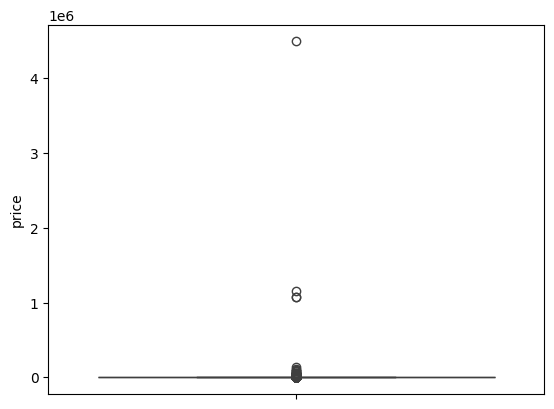

In [13]:
sns.boxplot(y=train_df['price'])
plt.show()

In [14]:
# clean_df = train_df.copy()
upper_bound = train_df['price'].quantile(0.99)
lower_bound = train_df['price'].quantile(0.01)

In [15]:
train_df.loc[train_df['price'] < lower_bound,'price'] = lower_bound
train_df.loc[train_df['price'] > upper_bound,'price'] = upper_bound

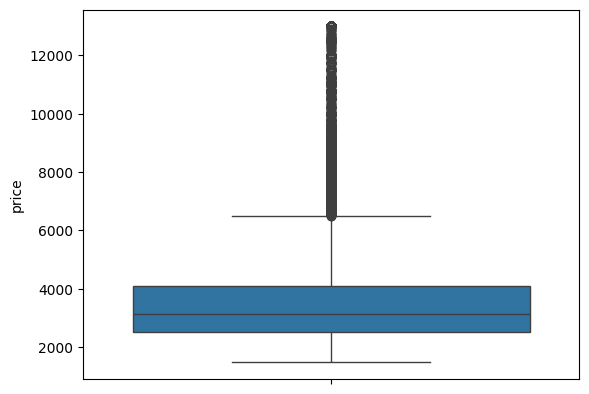

In [16]:
sns.boxplot(y=train_df['price'])
plt.show()

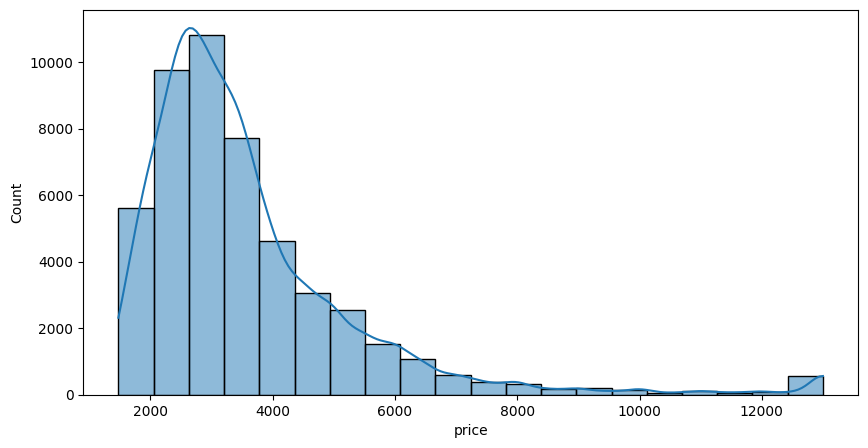

In [17]:
plt.figure(figsize=(10, 5))
sns.histplot(data=train_df, x='price', kde=True, bins=20)
plt.show()

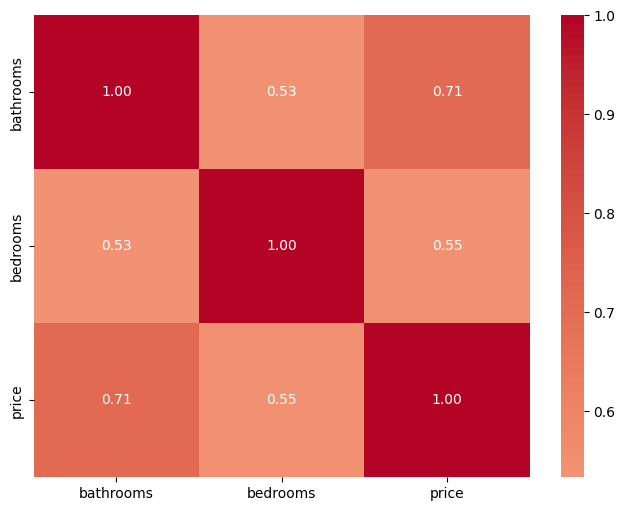

In [18]:
plt.figure(figsize=(8, 6))

corr_matrix = train_df[['bathrooms', 'bedrooms', 'price']].corr(method='pearson')
sns.heatmap(data=corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', center=0)

plt.show()

## Преобразование признаков

In [19]:
mapping_dict = {'low': 0, 'medium': 1, 'high': 2}
train_df['interest_level'] = train_df['interest_level'].map(mapping_dict)

In [20]:
train_df['features'] = train_df['features'].apply(lambda x: [i.replace(' ', '').strip(',\'\"') for i in x])

In [21]:
all_features = [] 

for el in train_df['features']: 
    all_features.extend(el)

In [22]:
top_20_features = [i[0] for i in Counter(all_features).most_common(20)]
top_20_features

['Elevator',
 'CatsAllowed',
 'HardwoodFloors',
 'DogsAllowed',
 'Doorman',
 'Dishwasher',
 'NoFee',
 'LaundryinBuilding',
 'FitnessCenter',
 'Pre-War',
 'LaundryinUnit',
 'RoofDeck',
 'OutdoorSpace',
 'DiningRoom',
 'HighSpeedInternet',
 'Balcony',
 'SwimmingPool',
 'LaundryInBuilding',
 'NewConstruction',
 'Terrace']

In [23]:
for feature_name in top_20_features: 
    train_df[feature_name] = train_df['features'].apply(lambda x: 1 if feature_name in x else 0)

In [24]:
feature_list = ['bathrooms', 'bedrooms'] +  top_20_features

# 2.1 Разделение данных на X и y

In [25]:
X = train_df[['created', 'interest_level'] + feature_list]
y = train_df['price']

In [26]:
X.head(1)

,created,interest_level,bathrooms,bedrooms,Elevator,CatsAllowed,HardwoodFloors,DogsAllowed,Doorman,Dishwasher,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,2016-06-16 05:55:27,1,1.0,1,0,1,1,1,0,1,...,0,0,0,1,0,0,0,0,0,0


In [27]:
y.head(1)

4    2400
Name: price, dtype: int64

# 3. Тестирование различных методов разделения данных

## Функционал класса DataSplit

In [28]:
data_splitter = DataSplit(X, y)

### Функция 1. Базовое разделение train_test_split

In [29]:
X_train, y_train, X_test, y_test = data_splitter.my_train_test_split(
    test_size=0.2, random_state=21, shuffle=True
)

In [30]:
X_train.shape[0] / X.shape[0], X_test.shape[0] / X.shape[0]

(0.8000081050413357, 0.1999918949586643)

In [31]:
y_train.shape[0] / y.shape[0], y_test.shape[0] / y.shape[0]

(0.8000081050413357, 0.1999918949586643)

### Функция 2. Разделение на train, valid и test

In [32]:
X_train, y_train, X_valid, y_valid, X_test, y_test = data_splitter.my_train_valid_test_split(
    test_size=0.2, valid_size=0.1, random_state=21, shuffle=True
)

In [33]:
X_train.shape[0] / X.shape[0], X_valid.shape[0] / X.shape[0], X_test.shape[0] / X.shape[0]

(0.7000121575620035, 0.09999594747933215, 0.1999918949586643)

In [34]:
y_train.shape[0] / y.shape[0], y_valid.shape[0] / y.shape[0], y_test.shape[0] / y.shape[0]

(0.7000121575620035, 0.09999594747933215, 0.1999918949586643)

### Функция 3. Разделение по дате на train и test

In [35]:
X_train, y_train, X_test, y_test = data_splitter.my_time_train_test_split(
    date_split='2016-06-12', date_column='created', ascending=True
)

In [36]:
X_train['created'].min(), X_train['created'].max()

(Timestamp('2016-04-01 22:12:41'), Timestamp('2016-06-11 23:54:30'))

In [37]:
X_test['created'].min(), X_test['created'].max()

(Timestamp('2016-06-12 00:23:43'), Timestamp('2016-06-29 21:41:47'))

### Функция 4. Разделение по дате на train, valid, test

In [38]:
X_train, y_train, X_valid, y_valid, X_test, y_test = data_splitter.my_time_train_valid_test_split(
    valid_date_split='2016-05-01', test_date_split='2016-06-01', date_column='created'
)

In [39]:
X_train['created'].min(), X_train['created'].max()

(Timestamp('2016-04-01 22:12:41'), Timestamp('2016-04-30 19:21:03'))

In [40]:
X_valid['created'].min(), X_valid['created'].max()

(Timestamp('2016-05-01 22:36:52'), Timestamp('2016-05-31 23:10:48'))

In [41]:
X_test['created'].min(), X_test['created'].max()

(Timestamp('2016-06-01 01:10:37'), Timestamp('2016-06-29 21:41:47'))

# 4-5. Тестирование различных методов кросс валидации

## Функционал класса Validation

In [42]:
val = Validation()

### Функция 1. K-Fold

#### Моя реализация K-Fold

In [43]:
my_test = val.my_KFold(
    n_samples=10, 
    n_splits=5, 
    shuffle=False
)
for train_idx, test_idx in my_test: 
    print(train_idx, test_idx)

[2 3 4 5 6 7 8 9] [0 1]
[0 1 4 5 6 7 8 9] [2 3]
[0 1 2 3 6 7 8 9] [4 5]
[0 1 2 3 4 5 8 9] [6 7]
[0 1 2 3 4 5 6 7] [8 9]


In [44]:
my_test = val.my_KFold(
    n_samples=len(train_df), 
    n_splits=5, 
    shuffle=False
)

for train_idx, test_idx in my_test: 
    print(f'Длина фолда train выборки: {len(train_idx)}, длина фолда test выборки {len(test_idx)}')

Длина фолда train выборки: 39481, длина фолда test выборки 9871
Длина фолда train выборки: 39481, длина фолда test выборки 9871
Длина фолда train выборки: 39482, длина фолда test выборки 9870
Длина фолда train выборки: 39482, длина фолда test выборки 9870
Длина фолда train выборки: 39482, длина фолда test выборки 9870


#### Встроенная

In [45]:
sklearn_test = KFold(
    n_splits=5, 
    shuffle=False
)
test_arr = np.arange(10)
for train_idx, test_idx in sklearn_test.split(test_arr): 
    print(train_idx, test_idx)
    

[2 3 4 5 6 7 8 9] [0 1]
[0 1 4 5 6 7 8 9] [2 3]
[0 1 2 3 6 7 8 9] [4 5]
[0 1 2 3 4 5 8 9] [6 7]
[0 1 2 3 4 5 6 7] [8 9]


In [46]:
for train_idx, test_idx in sklearn_test.split(train_df): 
    print(f'Длина фолда train выборки: {len(train_idx)}, длина фолда test выборки {len(test_idx)}')

Длина фолда train выборки: 39481, длина фолда test выборки 9871
Длина фолда train выборки: 39481, длина фолда test выборки 9871
Длина фолда train выборки: 39482, длина фолда test выборки 9870
Длина фолда train выборки: 39482, длина фолда test выборки 9870
Длина фолда train выборки: 39482, длина фолда test выборки 9870


### Функция 2. Grouped K-Fold

#### Моя реализация Grouped K-Fold

In [47]:
groups_arr = [0, 0, 0, 1, 2, 3, 0, 1, 1, 2, 3, 3, 2, 2, 3, 0]
my_test = val.my_groupedKFold(groups=groups_arr, n_splits=4, shuffle_groups=False)

for train_idx, test_idx in my_test: 
    print(train_idx, test_idx)

[ 3  7  8  4  9 12 13  5 10 11 14] [ 0  1  2  6 15]
[ 0  1  2  6 15  4  9 12 13  5 10 11 14] [3 7 8]
[ 0  1  2  6 15  3  7  8  5 10 11 14] [ 4  9 12 13]
[ 0  1  2  6 15  3  7  8  4  9 12 13] [ 5 10 11 14]


In [48]:
train_df.sample(1)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
77170,1.0,2,0,2016-05-22 01:16:10,This is a lovely 2 bedroom unit in a beautiful...,East 85th Street,"[Pre-War, DogsAllowed, CatsAllowed]",40.7748,7051033,-73.9462,...,0,0,0,0,0,0,0,0,0,0


In [49]:
groups_df = train_df['bedrooms']
my_test = val.my_groupedKFold(groups_df, n_splits=5, shuffle_groups=True)


for train_idx, test_idx in my_test: 
    print(f'Длина фолда train выборки: {len(train_idx)}, длина фолда test выборки {len(test_idx)}')
    # display(train_df.iloc[train_idx].sample(1))


Длина фолда train выборки: 24125, длина фолда test выборки 25227
Длина фолда train выборки: 47176, длина фолда test выборки 2176
Длина фолда train выборки: 49304, длина фолда test выборки 48
Длина фолда train выборки: 42074, длина фолда test выборки 7278
Длина фолда train выборки: 34729, длина фолда test выборки 14623


#### Встроенная

In [50]:
sklearn_test = GroupKFold(n_splits=4) 

for train_idx, test_idx in sklearn_test.split(groups_arr, groups=groups_arr): 
    print(train_idx, test_idx)

[ 3  4  5  7  8  9 10 11 12 13 14] [ 0  1  2  6 15]
[ 0  1  2  3  4  6  7  8  9 12 13 15] [ 5 10 11 14]
[ 0  1  2  3  5  6  7  8 10 11 14 15] [ 4  9 12 13]
[ 0  1  2  4  5  6  9 10 11 12 13 14 15] [3 7 8]


In [51]:
sklearn_test = GroupKFold(n_splits=5) 
for train_idx, test_idx in sklearn_test.split(train_df, groups=groups_df): 
    print(f'Длина фолда train выборки: {len(train_idx)}, длина фолда test выборки {len(test_idx)}')

Длина фолда train выборки: 33600, длина фолда test выборки 15752
Длина фолда train выборки: 34729, длина фолда test выборки 14623
Длина фолда train выборки: 39877, длина фолда test выборки 9475
Длина фолда train выборки: 42076, длина фолда test выборки 7276
Длина фолда train выборки: 47126, длина фолда test выборки 2226


#### Вывод
GroupKFold и my_groupedKFold разбивают данные на немного разные длины, так как в оригинальной по другому реализовано распределение остатка элементов при делении на фолды

### Функция 3. Stratified KFold

#### Моя реализация Stratified KFold

In [52]:
test_arr = np.array([0] * 7 + [1] * 3)
my_test = val.my_stratifiedKFold(test_arr, n_splits=3, shuffle=False)
for train_idx, test_idx in my_test: 
    print(train_idx, test_idx)

[3 4 5 6 8 9] [0 1 2 7]
[0 1 2 5 6 7 9] [3 4 8]
[0 1 2 3 4 7 8] [5 6 9]


In [53]:
# разделил по бинам целевую переменную
target_bins = pd.qcut(train_df['price'], q=10, labels=False, duplicates='drop')

my_test = val.my_stratifiedKFold(target_bins, n_splits=5, shuffle=False)

for train_idx, test_idx in my_test: 
    print(f'Длина фолда train выборки: {len(train_idx)}, длина фолда test выборки {len(test_idx)}')

Длина фолда train выборки: 39477, длина фолда test выборки 9875
Длина фолда train выборки: 39481, длина фолда test выборки 9871
Длина фолда train выборки: 39482, длина фолда test выборки 9870
Длина фолда train выборки: 39483, длина фолда test выборки 9869
Длина фолда train выборки: 39485, длина фолда test выборки 9867


#### Встроенная

In [54]:
sklearn_test = StratifiedKFold(n_splits=3)
for train_idx, test_idx in sklearn_test.split(test_arr, test_arr): 
    print(train_idx, test_idx)

[3 4 5 6 8 9] [0 1 2 7]
[0 1 2 5 6 7 9] [3 4 8]
[0 1 2 3 4 7 8] [5 6 9]


In [55]:
sklearn_test = StratifiedKFold(n_splits=5)
for train_idx, test_idx in sklearn_test.split(train_df, target_bins): 
    print(f'Длина фолда train выборки: {len(train_idx)}, длина фолда test выборки {len(test_idx)}')

Длина фолда train выборки: 39481, длина фолда test выборки 9871
Длина фолда train выборки: 39481, длина фолда test выборки 9871
Длина фолда train выборки: 39482, длина фолда test выборки 9870
Длина фолда train выборки: 39482, длина фолда test выборки 9870
Длина фолда train выборки: 39482, длина фолда test выборки 9870


#### Вывод
StratifiedKFold и my_stratifiedKFold разбивают данные на немного разные длины, так как в оригинальной по другому реализовано распределение остатка элементов при делении на фолды

### Функция 4. TimeSeriesSplit

In [56]:
sample_df = train_df.head(10) 
sample_df.head(1)

,bathrooms,bedrooms,building_id,created,description,display_address,features,latitude,listing_id,longitude,...,LaundryinUnit,RoofDeck,OutdoorSpace,DiningRoom,HighSpeedInternet,Balcony,SwimmingPool,LaundryInBuilding,NewConstruction,Terrace
4,1.0,1,8579a0b0d54db803821a35a4a615e97a,2016-06-16 05:55:27,Spacious 1 Bedroom 1 Bathroom in Williamsburg!...,145 Borinquen Place,"[DiningRoom, Pre-War, LaundryinBuilding, Dishw...",40.7108,7170325,-73.9539,...,0,0,0,1,0,0,0,0,0,0


#### Моя реализация TimeSeriesSplit (сортирую по датам внутри функции)

In [57]:
my_test = val.my_timeseries_split_indices(sample_df['created'], n_splits=5)
for train_idx, test_idx in my_test: 
    print(train_idx, test_idx)

[1] [7]
[1 7] [6]
[1 7 6] [8]
[1 7 6 8] [2]
[1 7 6 8 2] [0 3 9 4 5]


In [58]:
my_test = val.my_timeseries_split_indices(train_df['created'], n_splits=5)
for train_idx, test_idx in my_test: 
    print(f'Длина фолда train выборки: {len(train_idx)}, длина фолда test выборки {len(test_idx)}')

Длина фолда train выборки: 8225, длина фолда test выборки 8225
Длина фолда train выборки: 16450, длина фолда test выборки 8225
Длина фолда train выборки: 24675, длина фолда test выборки 8225
Длина фолда train выборки: 32900, длина фолда test выборки 8225
Длина фолда train выборки: 41125, длина фолда test выборки 8227


#### Встроенная
Реализация TimeSeriesSplit ожидает, что на вход поступают сразу отсортированные данные, в отличие от моей реализации, которая сортирует данные внутри функции

In [59]:
sklearn_test = TimeSeriesSplit(n_splits=5)
for train_idx, test_idx in sklearn_test.split(sample_df): # выдает неверные индексы, так как я отправляю не отсортированный массив в фун-ю
    print(train_idx, test_idx)

[0 1 2 3 4] [5]
[0 1 2 3 4 5] [6]
[0 1 2 3 4 5 6] [7]
[0 1 2 3 4 5 6 7] [8]
[0 1 2 3 4 5 6 7 8] [9]


In [60]:
sklearn_test = TimeSeriesSplit(n_splits=5)
for train_idx, test_idx in sklearn_test.split(train_df): 
    print(f'Длина фолда train выборки: {len(train_idx)}, длина фолда test выборки {len(test_idx)}')

Длина фолда train выборки: 8227, длина фолда test выборки 8225
Длина фолда train выборки: 16452, длина фолда test выборки 8225
Длина фолда train выборки: 24677, длина фолда test выборки 8225
Длина фолда train выборки: 32902, длина фолда test выборки 8225
Длина фолда train выборки: 41127, длина фолда test выборки 8225


#### Проверка с изначально отсортированными данными (должны быть одинаковые индексы)

In [61]:
sample_df = sample_df.sort_values('created').reset_index(drop=True)

In [62]:
my_test = val.my_timeseries_split_indices(sample_df['created'], n_splits=3)
for train_idx, test_idx in my_test: 
    print(train_idx, test_idx)

[0 1] [2 3]
[0 1 2 3] [4 5]
[0 1 2 3 4 5] [6 7 8 9]


In [63]:
sklearn_test = TimeSeriesSplit(n_splits=4)
for train_idx, test_idx in sklearn_test.split(sample_df): 
    print(train_idx, test_idx)

[0 1] [2 3]
[0 1 2 3] [4 5]
[0 1 2 3 4 5] [6 7]
[0 1 2 3 4 5 6 7] [8 9]


### Сравните все схемы проверки. Выберите лучшую. Объясните свой выбор.
Каждая из реализаций решает конкретную задачу, поэтому в контексте логики работы функций нельзя выбрать «лучшую» и «худшую» функцию 

* Для задачи прогнозирования цены на квартиры, на мой взгляд, лучше всего подойдет Stratified KFold - так мы сможем обучать и тестировать модель на одинаковом расредлении целевой переменной price, это исключает возможность получить на обучении модели только низкие цены, а на предсказание только большие и наоборот

* Так же, развивая эту идею, можно ввести новый категориальный столбец, зависящий от цены: 
    1. эконом жилье
    2. жилье среднего класса 
    3. роскошное жилье 
    4. и т.д 


    Это позволит нам использовать GroupKFold, который тоже будет распределять виды цены на жилье в нашей тренировочной и тестовой выборке

# 6. Отбор признаков (feature selection)

### Постройте модель регрессии Lasso с нормализованными признаками. 
Используйте свой метод разделения выборок на 3 части по полям, созданным в соотношении 60/20/20 — обучающая/валидационная/тестовая выборки.
Нормализую только колонки bathrooms и bedrooms, так как остальные колонки - бинарные признаки

In [64]:
X = X.drop('created', axis=1)

In [65]:
X_train, y_train, X_valid, y_valid, X_test, y_test = DataSplit(X, y).my_train_valid_test_split(test_size=0.2, valid_size=0.2)

In [66]:
scaler = MinMaxScaler()
X_train[['bathrooms', 'bedrooms']] = scaler.fit_transform(X_train[['bathrooms', 'bedrooms']]) # type: ignore

In [67]:
X_valid[['bathrooms', 'bedrooms']] = scaler.transform(X_valid[['bathrooms', 'bedrooms']]) # type: ignore
X_test[['bathrooms', 'bedrooms']] = scaler.transform(X_test[['bathrooms', 'bedrooms']]) # type: ignore

In [68]:
lasso_model = Lasso()

In [69]:
lasso_model.fit(pd.DataFrame(X_train), y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


### Отсортируйте признаки по весовым коэффициентам модели

In [70]:
coef = lasso_model.coef_
lasso_features = X_train.columns
len(coef), len(lasso_features)

(23, 23)

In [71]:
# %%timeit
# importance_features = pd.DataFrame({
#     'feature': lasso_features,
#     'coef': coef,
#     'abs_coef': np.abs(coef)
# }).sort_values('abs_coef', ascending=False).reset_index(drop=True)

In [72]:
importance_features = pd.DataFrame({
    'feature': lasso_features,
    'coef': coef,
    'abs_coef': np.abs(coef)
}).sort_values('abs_coef', ascending=False).reset_index(drop=True)

In [73]:
importance_features

,feature,coef,abs_coef
0,bathrooms,17424.622848,17424.622848
1,bedrooms,3326.007518,3326.007518
2,Doorman,603.501273,603.501273
3,LaundryinUnit,498.643041,498.643041
4,interest_level,-454.740590,454.740590
5,Terrace,250.615497,250.615497
6,LaundryinBuilding,-237.118365,237.118365
7,HighSpeedInternet,-206.990309,206.990309
8,Elevator,203.283490,203.283490
9,DiningRoom,193.465234,193.465234


### Обучите модель на 10 наиболее важных признаках и сравните их качество.

In [74]:
most_important_features = importance_features.head(10)['feature'].tolist()
most_important_features

['bathrooms',
 'bedrooms',
 'Doorman',
 'LaundryinUnit',
 'interest_level',
 'Terrace',
 'LaundryinBuilding',
 'HighSpeedInternet',
 'Elevator',
 'DiningRoom']

In [75]:
lasso_model_top_10_features = Lasso() 
lasso_model_top_10_features.fit(X_train[most_important_features], y_train) # type: ignore

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [76]:
lasso_top_10_predict = calculate_metrics(y_valid, lasso_model_top_10_features.predict(X_valid[most_important_features]), model_name='Lasso top 10 features (on valid)') # type: ignore
lasso_original_predict = calculate_metrics(y_valid, lasso_model.predict(X_valid), model_name='Lasso (on valid)') # type: ignore

In [77]:
metrics_frame = pd.concat([lasso_original_predict, lasso_top_10_predict]).reset_index(drop=True)
metrics_frame

,model,R2,MAE,RMSE,MSE
0,Lasso (on valid),0.612298,741.550135,1129.932538,1.276748e+06
1,Lasso top 10 features (on valid),0.608693,745.563055,1135.173664,1.288619e+06


### Реализация метода отбора признаков по соотношению NaN в признаках и корреляции с целевой переменной

In [78]:
lasso_model_corr = Lasso() 

In [79]:
# %%timeit
# selected_features = simple_features_selection(X_train, y_train, top_n=10)

In [80]:
selected_features = simple_features_selection(X_train, y_train, top_n=10)

In [81]:
lasso_model_corr.fit(X_train[selected_features], y_train)  # type: ignore


,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [82]:
corr_metrics = calculate_metrics(y_valid, lasso_model_corr.predict(X_valid[selected_features]), model_name='Lasso with corr features (on valid)') # type: ignore

In [83]:
metrics_frame = pd.concat([metrics_frame, corr_metrics]).reset_index(drop=True)

In [84]:
metrics_frame

,model,R2,MAE,RMSE,MSE
0,Lasso (on valid),0.612298,741.550135,1129.932538,1.276748e+06
1,Lasso top 10 features (on valid),0.608693,745.563055,1135.173664,1.288619e+06
2,Lasso with corr features (on valid),0.605518,748.221076,1139.769089,1.299074e+06


### Permutation importance method

In [85]:
permutation_lasso_model = Lasso()

In [86]:
permutation_lasso_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [87]:
# %%timeit
# imp = permutation_features(
#     model      = permutation_lasso_model,
#     X          = X_valid,
#     y          = y_valid,
#     n_repeats  = 12,
#     random_state = 21,
#     metric     = 'rmse'
# )
# imp

In [88]:
imp = permutation_features(
    model      = permutation_lasso_model,
    X          = X_valid,
    y          = y_valid,
    n_repeats  = 12,
    random_state = 21,
    metric     = 'rmse'
)
imp

Baseline RMSE: 1,129.9325


,feature,importance_mean,importance_std
0,bathrooms,536.446442,6.771649
1,bedrooms,212.946585,4.683066
2,Doorman,73.762008,3.964589
3,interest_level,69.931312,3.357411
4,LaundryinUnit,31.081386,1.802319
5,Elevator,9.810232,0.821401
6,LaundryinBuilding,8.266379,1.107690
7,FitnessCenter,5.845620,0.747026
8,Dishwasher,3.879415,0.673695
9,HighSpeedInternet,3.358733,0.577049


In [89]:
perm_result = permutation_importance(
    permutation_lasso_model, 
    X_valid, 
    y_valid,
    scoring='neg_mean_squared_error',    
    n_repeats=10,
    random_state=21,
    n_jobs=-1
)

In [90]:
df_perm = pd.DataFrame({
    'feature': X_valid.columns,
    'importance_mean': perm_result.importances_mean,
    'importance_std': perm_result.importances_std
})
df_perm = df_perm.sort_values('importance_mean', ascending=False).reset_index(drop=True)
df_perm

,feature,importance_mean,importance_std
0,bathrooms,1.497463e+06,32980.916803
1,bedrooms,5.205192e+05,11565.493970
2,Doorman,1.794838e+05,7077.802639
3,interest_level,1.624539e+05,3615.421472
4,LaundryinUnit,7.413988e+04,2318.060828
5,Elevator,2.240862e+04,2512.870621
6,LaundryinBuilding,1.886699e+04,2821.272419
7,FitnessCenter,1.384794e+04,1552.219257
8,Dishwasher,9.548232e+03,2022.545305
9,HighSpeedInternet,6.477967e+03,1464.333181


In [91]:
imp_features_list = imp['feature'].head(10).values
imp_features_list

<StringArray>
[        'bathrooms',          'bedrooms',           'Doorman',
    'interest_level',     'LaundryinUnit',          'Elevator',
 'LaundryinBuilding',     'FitnessCenter',        'Dishwasher',
 'HighSpeedInternet']
Length: 10, dtype: str

In [92]:
perm_model = Lasso() 
perm_model.fit(X_train[imp_features_list], y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [93]:
perm_metrics = calculate_metrics(y_valid, perm_model.predict(X_valid[imp_features_list]), model_name='Lasso model with permutation features (on valid)')


In [94]:
metrics_frame = pd.concat([metrics_frame, perm_metrics])
metrics_frame

,model,R2,MAE,RMSE,MSE
0,Lasso (on valid),0.612298,741.550135,1129.932538,1.276748e+06
1,Lasso top 10 features (on valid),0.608693,745.563055,1135.173664,1.288619e+06
2,Lasso with corr features (on valid),0.605518,748.221076,1139.769089,1.299074e+06
0,Lasso model with permutation features (on valid),0.608883,743.746677,1134.897405,1.287992e+06


### Shap

In [95]:
lasso_shap_model = Lasso()

In [96]:
lasso_shap_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [97]:
%%timeit
explainer = shap.LinearExplainer(lasso_shap_model, X_train)
shap_values = explainer.shap_values(X_valid)

shap_importance = pd.DataFrame({
    'feature': X_valid.columns,
    'shap_importance_mean': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance_mean', ascending=False).reset_index(drop=True)

2.2 ms ± 103 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [98]:
explainer = shap.LinearExplainer(lasso_shap_model, X_train)
shap_values = explainer.shap_values(X_valid)

shap_importance = pd.DataFrame({
    'feature': X_valid.columns,
    'shap_importance_mean': np.abs(shap_values).mean(axis=0)
}).sort_values('shap_importance_mean', ascending=False).reset_index(drop=True)

Столбец shap_importance_mean показывает:
* Средний абсолютный вклад каждого признака в предсказание модели (в единицах целевой переменной — в долларах, так как это цена аренды/продажи).
* Чем выше значение - тем больше в среднем этот признак двигает предсказание модели вверх или вниз.

In [99]:
shap_importance

,feature,shap_importance_mean
0,bathrooms,624.726574
1,bedrooms,443.311695
2,Doorman,291.971103
3,interest_level,249.407936
4,LaundryinUnit,149.745486
5,Elevator,101.763262
6,LaundryinBuilding,100.026472
7,FitnessCenter,73.909048
8,HardwoodFloors,69.673052
9,Dishwasher,61.025782


In [100]:
shap_features = shap_importance.head(10)['feature'].values.tolist()
shap_features

['bathrooms',
 'bedrooms',
 'Doorman',
 'interest_level',
 'LaundryinUnit',
 'Elevator',
 'LaundryinBuilding',
 'FitnessCenter',
 'HardwoodFloors',
 'Dishwasher']

In [101]:
lasso_shap_model.fit(X_train[shap_features], y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [102]:
shap_metrics = calculate_metrics(y_valid, lasso_shap_model.predict(X_valid[shap_features]), model_name='Lasso with shap features on valid')

In [103]:
metrics_frame = pd.concat([metrics_frame, shap_metrics])

In [104]:
metrics_frame

,model,R2,MAE,RMSE,MSE
0,Lasso (on valid),0.612298,741.550135,1129.932538,1.276748e+06
1,Lasso top 10 features (on valid),0.608693,745.563055,1135.173664,1.288619e+06
2,Lasso with corr features (on valid),0.605518,748.221076,1139.769089,1.299074e+06
0,Lasso model with permutation features (on valid),0.608883,743.746677,1134.897405,1.287992e+06
0,Lasso with shap features on valid,0.607801,745.488054,1136.466949,1.291557e+06


### Сравнение качества метрик, скорости и стабильности у различных методов 

#### Фрейм с метриками

In [105]:
metrics_frame

,model,R2,MAE,RMSE,MSE
0,Lasso (on valid),0.612298,741.550135,1129.932538,1.276748e+06
1,Lasso top 10 features (on valid),0.608693,745.563055,1135.173664,1.288619e+06
2,Lasso with corr features (on valid),0.605518,748.221076,1139.769089,1.299074e+06
0,Lasso model with permutation features (on valid),0.608883,743.746677,1134.897405,1.287992e+06
0,Lasso with shap features on valid,0.607801,745.488054,1136.466949,1.291557e+06


#### Сравнение: 
1) **```Обучение на 10 признаках с наибольшими по модулю коэффициентами w из модели```**

* Время: 116 μs ± 7.01 μs per loop (mean ± std. dev. of 7 runs, 10,000 loops each)

* Метрики:&emsp;&emsp;&ensp;```R2```: $0.608693$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;```MSE```: $1.288619e+06$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;```RMSE```: $1135.173664$<br>

* Стабильность: поскольку данные не меняют своё рапределение в выборках, то алгоритм работает стабильно


2) **```Обучение на 10 признаках, для которых максимальна корреляция с целевой переменной и нет большого количества пропусков```**

* Время: 8.31 ms ± 78.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)<br>

* Метрики:&emsp;&emsp;&ensp;```R2```: $0.605518$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;```MSE```: $1.299074e+06$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;```RMSE```: $1139.769089$<br>

* Стабильность: поскольку данные не меняют своё рапределение в выборках, то алгоритм работает стабильно


3) **```Обучение на 10 признаках, выбранных с помощью Permutation Importance```**

* Время: 357 ms ± 26.7 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)<br>

* Метрики:&emsp;&emsp;&ensp;```R2```: $0.608883$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;```MSE```: $1.287992e+06$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;```RMSE```: $1134.897405$<br>

* Стабильность: алгоритм зависит от случайного разбиения (перемешивания) признаков внутри метода, поэтому состав признаков меняется и метрика получается разная

4) **```Обучение на 10 признаках, выбранных с помощью SHAP```**

* Время: 2.34 ms ± 373 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)<br>

* Метрики:&emsp;&emsp;&ensp;```R2```: $0.607801$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;```MSE```: $1.291557e+06$<br>
&emsp;&emsp;&emsp;&emsp;&emsp;&emsp;```RMSE```: $1136.466949$<br>

* Стабильность: поскольку данные не меняют своё рапределение в выборках, то алгоритм работает стабильно


#### Вывод: 
Лучшими с точки зрения метрик, скорости и стабильности оказались 1 и 4 алгоритмы (метод, основанный на выборе признаков по величине модуля коэффициентов и SHAP), выбор признаков работает даже быстрее, но не всегда будет настолько же полезен и лидирующем, как в контексте этой задачи. 

Худший результат как по времени, так и по метрикам и стабильности показал Permutation Importance

# 7. Оптимизация гиперпараметров

In [106]:
from sklearn.linear_model import ElasticNet
gd_test_model = ElasticNet()

In [107]:
param_grid = {
        'alpha': [0.001, 0.01, 0.1, 1.0],
        'l1_ratio': [0.1, 0.3, 0.5, 0.7, 1.0]
    }

## myGridSearchCV

In [108]:
from itertools import product 


class my_GridSearchCV: 
    def __init__(self, estimator, 
                param_grid: dict, 
                cv: int = 5) -> None: 
        
        self.estimator = estimator 
        self.param_grid = param_grid
        self.cv = cv 
        self.best_params_ = None 
        self.best_estimator_ = None
        self.scores_results = None
        
    def fit(self, X: pd.DataFrame | pd.Series, y:pd.Series, scoring: str = 'mse') -> 'my_GridSearchCV': 
        match scoring: 
            case 'rmse': 
                score_func = lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))
            case 'mse': 
                score_func = mean_squared_error
            case 'mae': 
                score_func = mean_absolute_error 
            case 'r2': 
                score_func = r2_score
            case _: 
                raise ValueError('Параметр scoring должен быть равен одному из следующих значений: "rmse", "mse", "mae", "r2"') 
        
        keys = list(self.param_grid.keys())
        KFold = Validation().my_KFold
        # metrics = []
        best_score = 10000000
        best_params = None
        scores_results = []
        for params in product(*self.param_grid.values()): 
            scores = []
            params_dict = dict(zip(keys, params))
            model = self.estimator(**params_dict)
            for train_idx, test_idx in KFold(n_samples=X.shape[0],n_splits=self.cv): 
                X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
                X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
                
                model.fit(X_train, y_train) 
                score = score_func(y_test, model.predict(X_test))
                scores.append(score)
            
            mean_score = np.round(np.mean(scores), 4)
            scores_results.append({'mean_score': mean_score, 'params': params_dict})
            if mean_score < best_score: 
                best_score = mean_score
                best_params = params_dict
                
        self.best_params_ = best_params
        final_model = self.estimator(**self.best_params_)
        final_model.fit(X, y)
        self.best_estimator_ = final_model
        self.scores_results = pd.DataFrame(sorted(scores_results, key=lambda x: x['mean_score']))
        
        return self

In [109]:
from sklearn.model_selection import GridSearchCV
grid = GridSearchCV(gd_test_model, param_grid=param_grid)
grid.fit(X, y)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",ElasticNet()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'alpha': [0.001, 0.01, ...], 'l1_ratio': [0.1, 0.3, ...]}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",None
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",None
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and parameter candidate is displayed;- >2 : the score is also displayed;- >3 : the fold and

In [110]:
grid.best_params_

{'alpha': 0.001, 'l1_ratio': 0.5}

In [111]:
my_grid = my_GridSearchCV(gd_test_model.__class__, param_grid=param_grid)
my_grid.fit(X, y, scoring='rmse')
my_grid.best_estimator_

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.001
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.3
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [112]:
my_grid.scores_results

,mean_score,params
0,1125.1491,"{'alpha': 0.001, 'l1_ratio': 0.3}"
1,1125.1492,"{'alpha': 0.001, 'l1_ratio': 0.5}"
2,1125.1499,"{'alpha': 0.001, 'l1_ratio': 0.1}"
3,1125.1502,"{'alpha': 0.001, 'l1_ratio': 0.7}"
4,1125.1534,"{'alpha': 0.001, 'l1_ratio': 1.0}"
5,1125.1534,"{'alpha': 0.01, 'l1_ratio': 1.0}"
6,1125.1554,"{'alpha': 0.1, 'l1_ratio': 1.0}"
7,1125.2083,"{'alpha': 0.01, 'l1_ratio': 0.7}"
8,1125.3114,"{'alpha': 1.0, 'l1_ratio': 1.0}"
9,1125.3397,"{'alpha': 0.01, 'l1_ratio': 0.5}"


## myRandomizedSearchCV

In [113]:
from sklearn.model_selection import RandomizedSearchCV

In [114]:
class my_RandomizedSearchCV: 
    def __init__(self, estimator, param_distributions: dict, cv: int = 5, n_iter: int = 20, random_state: int = 21) -> None:
        self.estimator = estimator
        self.param_distributions = param_distributions
        self.cv = cv
        self.n_iter = n_iter
        self.random_state = random_state 
        

    def fit(self, X: pd.DataFrame | pd.Series, y:pd.Series, scoring: str = 'mse') -> 'my_RandomizedSearchCV': 
        match scoring: 
            case 'rmse': 
                score_func = lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred))
            case 'mse': 
                score_func = mean_squared_error
            case 'mae': 
                score_func = mean_absolute_error 
            case 'r2': 
                score_func = r2_score
            case _: 
                raise ValueError('Параметр scoring должен быть равен одному из следующих значений: "rmse", "mse", "mae", "r2"') 
        
        # keys = list(self.param_distributions.keys())
        KFold = Validation().my_KFold
        # metrics = []
        best_score = 10000000
        best_params = None
        scores_results = []
        rng = np.random.default_rng(self.random_state)
        for i in range(self.n_iter): 
            scores = []
            params_dict = {}
            for key, values in self.param_distributions.items(): 
                params_dict[key] = rng.choice(values) 
                                
            model = self.estimator(**params_dict)
            for train_idx, test_idx in KFold(n_samples=X.shape[0],n_splits=self.cv): 
                X_train, y_train = X.iloc[train_idx], y.iloc[train_idx]
                X_test, y_test = X.iloc[test_idx], y.iloc[test_idx]
                
                model.fit(X_train, y_train) 
                score = score_func(y_test, model.predict(X_test))
                scores.append(score)
            
            mean_score = np.round(np.mean(scores), 4)
            scores_results.append({'mean_score': mean_score, 'params': params_dict})
            if scoring != 'r2':
                if mean_score < best_score: 
                    best_score = mean_score
                    best_params = params_dict
            else: 
                if mean_score > best_score: 
                    best_score = mean_score
                    best_params = params_dict

        self.best_params_ = best_params
        final_model = self.estimator(**self.best_params_)
        final_model.fit(X, y)
        self.best_estimator_ = final_model
        self.scores_results = pd.DataFrame(sorted(scores_results, key=lambda x: x['mean_score']))
        
        return self

In [115]:
test_rand_gd = my_RandomizedSearchCV(gd_test_model.__class__, param_grid, n_iter=10)

In [116]:
test_rand_gd.fit(X, y, scoring='rmse')
test_rand_gd.scores_results

,mean_score,params
0,1125.1492,"{'alpha': 0.001, 'l1_ratio': 0.5}"
1,1125.1554,"{'alpha': 0.1, 'l1_ratio': 1.0}"
2,1125.1554,"{'alpha': 0.1, 'l1_ratio': 1.0}"
3,1125.2083,"{'alpha': 0.01, 'l1_ratio': 0.7}"
4,1125.2083,"{'alpha': 0.01, 'l1_ratio': 0.7}"
5,1125.2083,"{'alpha': 0.01, 'l1_ratio': 0.7}"
6,1125.2083,"{'alpha': 0.01, 'l1_ratio': 0.7}"
7,1125.7951,"{'alpha': 0.01, 'l1_ratio': 0.1}"
8,1249.2239,"{'alpha': 1.0, 'l1_ratio': 0.7}"
9,1400.6981,"{'alpha': 1.0, 'l1_ratio': 0.1}"


## Сравнение результатов работы двух классов

In [117]:
#my_RandomizedSearchCV
best_params_rndm = test_rand_gd.best_params_
best_params_rndm

{'alpha': np.float64(0.001), 'l1_ratio': np.float64(0.5)}

In [118]:
test_rand_gd.scores_results

,mean_score,params
0,1125.1492,"{'alpha': 0.001, 'l1_ratio': 0.5}"
1,1125.1554,"{'alpha': 0.1, 'l1_ratio': 1.0}"
2,1125.1554,"{'alpha': 0.1, 'l1_ratio': 1.0}"
3,1125.2083,"{'alpha': 0.01, 'l1_ratio': 0.7}"
4,1125.2083,"{'alpha': 0.01, 'l1_ratio': 0.7}"
5,1125.2083,"{'alpha': 0.01, 'l1_ratio': 0.7}"
6,1125.2083,"{'alpha': 0.01, 'l1_ratio': 0.7}"
7,1125.7951,"{'alpha': 0.01, 'l1_ratio': 0.1}"
8,1249.2239,"{'alpha': 1.0, 'l1_ratio': 0.7}"
9,1400.6981,"{'alpha': 1.0, 'l1_ratio': 0.1}"


In [119]:
#my_GridSearchCV
best_params_gd = my_grid.best_params_
best_params_gd

{'alpha': 0.001, 'l1_ratio': 0.3}

In [120]:
my_grid.scores_results

,mean_score,params
0,1125.1491,"{'alpha': 0.001, 'l1_ratio': 0.3}"
1,1125.1492,"{'alpha': 0.001, 'l1_ratio': 0.5}"
2,1125.1499,"{'alpha': 0.001, 'l1_ratio': 0.1}"
3,1125.1502,"{'alpha': 0.001, 'l1_ratio': 0.7}"
4,1125.1534,"{'alpha': 0.001, 'l1_ratio': 1.0}"
5,1125.1534,"{'alpha': 0.01, 'l1_ratio': 1.0}"
6,1125.1554,"{'alpha': 0.1, 'l1_ratio': 1.0}"
7,1125.2083,"{'alpha': 0.01, 'l1_ratio': 0.7}"
8,1125.3114,"{'alpha': 1.0, 'l1_ratio': 1.0}"
9,1125.3397,"{'alpha': 0.01, 'l1_ratio': 0.5}"


## Обучение модели на лучших параметрах

In [121]:
gridsearch_result_model = ElasticNet(**best_params_gd)

In [122]:
gridsearch_result_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.001
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.3
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [123]:
gd_metrics = calculate_metrics(y_valid, gridsearch_result_model.predict(X_valid), model_name='GridSearch model (ElsticNet on valid)')

In [124]:
metrics_frame = pd.concat([metrics_frame, gd_metrics])
metrics_frame

,model,R2,MAE,RMSE,MSE
0,Lasso (on valid),0.612298,741.550135,1129.932538,1.276748e+06
1,Lasso top 10 features (on valid),0.608693,745.563055,1135.173664,1.288619e+06
2,Lasso with corr features (on valid),0.605518,748.221076,1139.769089,1.299074e+06
0,Lasso model with permutation features (on valid),0.608883,743.746677,1134.897405,1.287992e+06
0,Lasso with shap features on valid,0.607801,745.488054,1136.466949,1.291557e+06
0,GridSearch model (ElsticNet on valid),0.599988,754.328585,1147.731336,1.317287e+06


## Импорт optuna и проверка качества его работы

In [125]:
# !python3 -m pip uninstall -y optuna
# !python3 -m pip cache purge
# !python3 -m pip install --force-reinstall optuna

In [127]:
import optuna
from sklearn.model_selection import cross_val_score

In [ ]:
def objective(trial): 
    alpha = trial.suggest_float("alpha", 0.0, 1.0, step=0.1)
    l1_ratio   = trial.suggest_float("l1_ratio", 0.0, 1.0, step=0.1)
    max_iter = trial.suggest_int("max_iter", 500, 8000, step=500) 
    
    model = ElasticNet(alpha=alpha, l1_ratio=l1_ratio, max_iter=max_iter, random_state=21)
    
    score = np.sqrt(-cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error').mean())
    return score
    

In [135]:
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=40)

[I 2026-01-26 15:54:50,436] A new study created in memory with name: no-name-127f1ff6-9ab4-468a-bf31-a9572d9c517f
[I 2026-01-26 15:54:55,234] Trial 0 finished with value: 1706.8926635380274 and parameters: {'alpha': 0.7000000000000001, 'l1_ratio': 0.0, 'max_iter': 4000}. Best is trial 0 with value: 1706.8926635380274.
[I 2026-01-26 15:54:55,312] Trial 1 finished with value: 1707.0846881145835 and parameters: {'alpha': 1.0, 'l1_ratio': 0.30000000000000004, 'max_iter': 6500}. Best is trial 0 with value: 1706.8926635380274.
[I 2026-01-26 15:54:55,387] Trial 2 finished with value: 1642.5435210491705 and parameters: {'alpha': 0.6000000000000001, 'l1_ratio': 0.5, 'max_iter': 7000}. Best is trial 2 with value: 1642.5435210491705.
[I 2026-01-26 15:54:56,749] Trial 3 finished with value: 1121.3974736518578 and parameters: {'alpha': 0.0, 'l1_ratio': 0.5, 'max_iter': 1000}. Best is trial 3 with value: 1121.3974736518578.
[I 2026-01-26 15:54:56,829] Trial 4 finished with value: 1586.9067410421226 

In [138]:
optuna_elastic_model = ElasticNet(**study.best_params)
optuna_elastic_model.fit(X_train, y_train)

,"alpha alpha: float, default=1.0Constant that multiplies the penalty terms. Defaults to 1.0.See the notes for the exact mathematical meaning of thisparameter. ``alpha = 0`` is equivalent to an ordinary least square,solved by the :class:`LinearRegression` object. For numericalreasons, using ``alpha = 0`` with the ``Lasso`` object is not advised.Given this, you should use the :class:`LinearRegression` object.",0.0
,"l1_ratio l1_ratio: float, default=0.5The ElasticNet mixing parameter, with ``0 <= l1_ratio <= 1``. For``l1_ratio = 0`` the penalty is an L2 penalty. ``For l1_ratio = 1`` itis an L1 penalty. For ``0 < l1_ratio < 1``, the penalty is acombination of L1 and L2.",0.5
,"fit_intercept fit_intercept: bool, default=TrueWhether the intercept should be estimated or not. If ``False``, thedata is assumed to be already centered.",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.Check :ref:`an example on how to use a precomputed Gram Matrix in ElasticNet`for details.",False
,"max_iter max_iter: int, default=1000The maximum number of iterations.",1000
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-4The tolerance for the optimization: if the updates are smaller or equal to``tol``, the optimization code checks the dual gap for optimality and continuesuntil it is smaller or equal to ``tol``, see Notes below.",0.0001
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fit asinitialization, otherwise, just erase the previous solution.See :term:`the Glossary `.",False
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive.",False
,"random_state random_state: int, RandomState instance, default=NoneThe seed of the pseudo random number generator that selects a randomfeature to update. Used when ``selection`` == 'random'.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"selection selection: {'cyclic', 'random'}, default='cyclic'If set to 'random', a random coefficient is updated every iterationrather than looping over features sequentially by default. This(setting to 'random') often leads to significantly faster convergenceespecially when tol is higher than 1e-4.",'cyclic'


In [139]:
optuna_metrics = calculate_metrics(y_test, optuna_elastic_model.predict(X_test), model_name='Optuna ElasticNet (on valid)')
metrics_frame = pd.concat([metrics_frame, optuna_metrics])

In [141]:
metrics_frame

,model,R2,MAE,RMSE,MSE
0,Lasso (on valid),0.612298,741.550135,1129.932538,1.276748e+06
1,Lasso top 10 features (on valid),0.608693,745.563055,1135.173664,1.288619e+06
2,Lasso with corr features (on valid),0.605518,748.221076,1139.769089,1.299074e+06
0,Lasso model with permutation features (on valid),0.608883,743.746677,1134.897405,1.287992e+06
0,Lasso with shap features on valid,0.607801,745.488054,1136.466949,1.291557e+06
0,GridSearch model (ElsticNet on valid),0.599988,754.328585,1147.731336,1.317287e+06
0,Optuna ElasticNet (on valid),0.636557,747.582348,1132.476991,1.282504e+06
